In [ ]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..')) # Go up one level to the project root and add it to the path
from src.etl.ingest import load_nvdrs
from src.etl.transform import filter_nvdrs_suicides, aggregate_nvdrs_daily


import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import ExponentialSmoothing, AutoARIMA, LightGBMModel
import pickle
# If you just want to see the whole data config dictionary
#from src.utils.config import load_config
# data_config = load_config("data.yaml")

In [18]:
#usecols = ['IncidentID', 'IncidentYear', 'SiteID', 'IncidentNumber', 'IncidentCategory_c', 'HomicideSuicide_c', 'PersonID', 'VictimNumber', 'PersonType', 'NumberWeapons_c', 'NumberSuspects_c', 'NumberSubstances_c', 'NumberSubstancesCausedDeath_c', 'Sex', 'AgeYears_c', 'Country', 'ResidenceState', 'ResidenceFIPS', 'ResidenceCityState', 'ResidenceZip', 'Homeless', 'AbstractorDeathmanner_c', 'InjuryState', 'InjuryFIPS', 'InjuryCityState', 'InjuryZip', 'InjuryDate', 'InjuryDate_myr', 'InjuryDate_year', 'InjuryTime', 'InjuryLocationType', 'RecentRelease', 'AlcoholUseSuspected', 'ExternalCause1ICD9', 'ExternalCause2ICD9', 'UnderlyingCauseCode', 'DeathCause1', 'DeathCause2', 'DeathCause3', 'OtherCondition', 'HowInjuryOccurred', 'DeathDate', 'DeathDate_myr', 'DeathDate_year', 'DeathState', 'DeathFIPS', 'MultipleConditionCode01ICD10', 'MultipleConditionCode02ICD10', 'MultipleConditionCode03ICD10', 'MultipleConditionCode04ICD10', 'MultipleConditionCode05ICD10', 'MultipleConditionCode06ICD10', 'MultipleConditionCode07ICD10', 'MultipleConditionCode08ICD10', 'MultipleConditionCode09ICD10', 'MultipleConditionCode10ICD10', 'CME_CircumstancesOtherText', 'CME_CrisisOtherDescription', 'LE_CircumstancesOtherText', 'LE_CrisisOtherDescription', 'SuicideAttemptHistory_c', 'SuicideThoughtHistory_c', 'HistorySelfHarm_c']
#uselesscols = ['IncidentID', 'IncidentYear', 'SiteID', 'IncidentNumber', 'IncidentCategory_c', 'HomicideSuicide_c', 'PersonID', 'VictimNumber', 'PersonType', 'NumberSuspects_c', 'Sex', 'AgeYears_c', 'Country', 'AbstractorDeathmanner_c', 'InjuryState', 'InjuryFIPS', 'InjuryCityState', 'InjuryZip', 'InjuryDate', 'InjuryDate_myr', 'InjuryDate_year', 'InjuryTime', 'InjuryLocationType']
usemincol = ['IncidentID','InjuryDate','InjuryState','IncidentCategory_c','PersonType']

if 'nvdrs_df' not in locals():
    nvdrs_df = load_nvdrs(file_key="nvdrs", data_folder="raw", usecols=usemincol)

# Filter suicides
nvdrs_s_df = filter_nvdrs_suicides(nvdrs_df)
# starting from 01/01/2010
nvdrs_s_df = nvdrs_s_df[nvdrs_s_df['InjuryDate'] >= '2010-01-01']


# Create Univariate TimeSeries (US Total)
nvdrs_s_daily_df = aggregate_nvdrs_daily(nvdrs_s_df, by_state=False)

# from pands df to darts ts (US Total)
nvdrs_ts = TimeSeries.from_dataframe(
    nvdrs_s_daily_df, 
    time_col='InjuryDate', 
    value_cols='incident_count',
    fill_missing_dates=True, 
    freq='D',
    fillna_value=0
)

# Create Multivariate TimeSeries (By State)
agg_state_df = aggregate_nvdrs_daily(nvdrs_s_df, by_state=True)

nvdrs_ts_states = TimeSeries.from_dataframe(
    agg_state_df,
    time_col='InjuryDate',
    fill_missing_dates=True, 
    freq='D',                
    fillna_value=0           
)



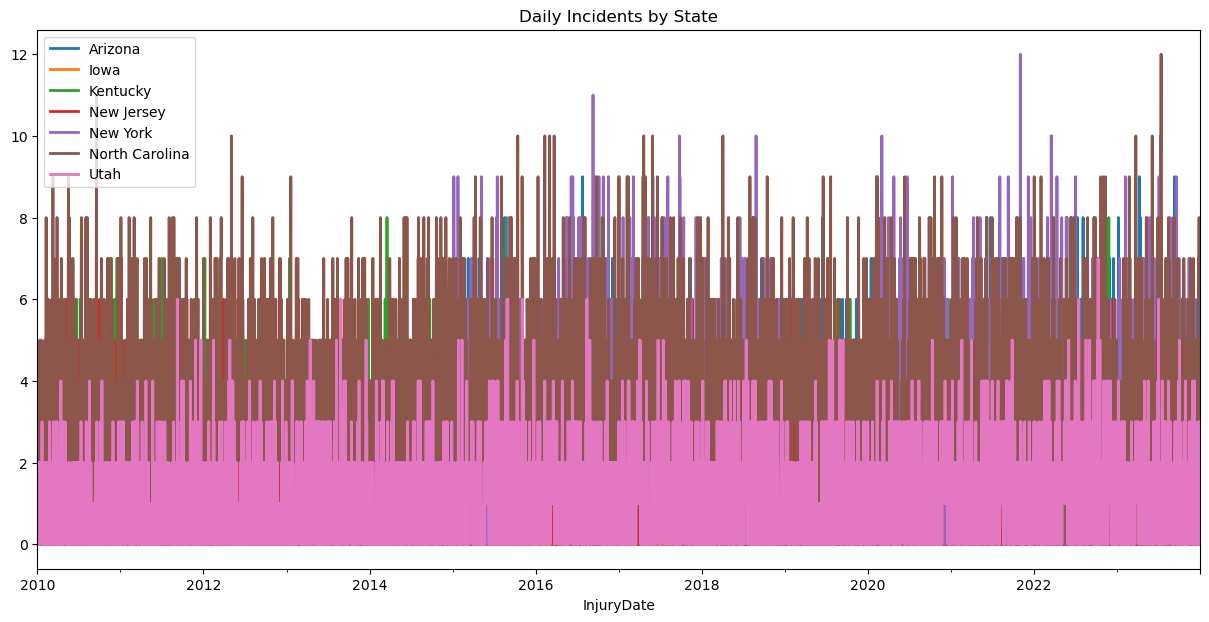

In [19]:
selected_states = ['Arizona', 'Iowa', 'Kentucky', 'New Jersey', 'New York', 'North Carolina', 'Utah']

plt.figure(figsize=(15, 7))
nvdrs_ts_states[selected_states].plot()

plt.title("Daily Incidents by State")
plt.show()

In [ ]:
# Extract, resample to Monthly ('ME') and Weekly ('W'), sum the daily counts, and plot
monthly_df = nvdrs_ts_states.to_dataframe().resample('ME').sum() #calculates
weekly_df = nvdrs_ts_states.to_dataframe().resample('W').sum() #calculates
daily_df = nvdrs_ts_states.to_dataframe()


# Filter the monthly dataframe to just these columns and plot
monthly_df[selected_states].plot(figsize=(15, 7))

plt.title("Monthly Incidents for Selected States")
plt.ylabel("Incident Count")
plt.xlabel("Date")
plt.show()



weekly_df[selected_states].plot(figsize=(15, 7))

plt.title("weekly Incidents for Selected States")
plt.ylabel("Incident Count")
plt.xlabel("Date")
plt.show()



daily_df[selected_states].plot(figsize=(15, 7))

plt.title("Daily Incidents for Selected States")
plt.ylabel("Incident Count")
plt.xlabel("Date")
plt.show()

In [ ]:
state= 'North Carolina'

# 1. Convert pandas DataFrame back to a Darts TimeSeries
ts_monthly = TimeSeries.from_dataframe(monthly_df.reset_index(), time_col='InjuryDate')
ts_weekly = TimeSeries.from_dataframe(weekly_df.reset_index(), time_col='InjuryDate')
ts_daily = TimeSeries.from_dataframe(daily_df.reset_index(), time_col='InjuryDate')

# 2. Isolate one state (simple ESs require univariate series)
ts_state_m = ts_monthly[state]
ts_state_w = ts_weekly[state]
ts_state_d = ts_daily[state]

# 3. Split data (train on history, validate on the last 36 months)
train_m, val_m = ts_state_m[:-20], ts_state_m[-20:]
train_w, val_w = ts_state_w[:-50], ts_state_w[-50:]
train_d, val_d = ts_state_d[:-90], ts_state_d[-90:]



# Exponential smoothing (univariate)
# 4. Initialize and fit
ES_m = ExponentialSmoothing()
ES_m.fit(train_m)
ES_w = ExponentialSmoothing()
ES_w.fit(train_w)
ES_d = ExponentialSmoothing()
ES_d.fit(train_d)

# 5. Predict and plot
ES_pred_m = ES_m.predict(len(val_m))
ES_pred_w = ES_w.predict(len(val_w))
ES_pred_d = ES_d.predict(len(val_d))

ts_state_m.plot(label='Actual')
ES_pred_m.plot(label='ExponentialSmoothing', lw=2)
plt.legend()
plt.title(state + ' - monthly')
plt.show()


ts_state_w.plot(label='Actual')
ES_pred_w.plot(label='ExponentialSmoothing - weekly', lw=2)
plt.legend()
plt.title(state + ' - weekly')
plt.show()


ts_state_d.plot(label='Actual')
ES_pred_d.plot(label='ExponentialSmoothing - daily', lw=2)
plt.legend()
plt.title(state + ' - daily')
plt.show()









# AutoArima (univariate)

# Initialize and fit on a state
AA_m = AutoARIMA()
AA_m.fit(train_m)

# Predict and plot
AA_pred_m = AA_m.predict(len(val_m))

ts_state_m.plot(label='Actual')
AA_pred_m.plot(label='AutoArima', lw=2)
plt.legend()
plt.title(state + ' - Monthly')
plt.show()


AA_w = AutoARIMA()
AA_w.fit(train_w)

# Predict and plot
AA_pred_w = AA_w.predict(len(val_w))

ts_state_w.plot(label='Actual')
AA_pred_w.plot(label='AutoArima', lw=2)
plt.legend()
plt.title(state + ' - Weekly')
plt.show()



AA_d = AutoARIMA()
AA_d.fit(train_d)

# Predict and plot
AA_pred_d = AA_d.predict(len(val_d))

ts_state_d.plot(label='Actual')
AA_pred_d.plot(label='AutoArima', lw=2)
plt.legend()
plt.title(state + ' - Daily')
plt.show()



In [ ]:
# 1. Split the entire multivariate series (all states)
train_multi, val_multi = ts_monthly[:-36], ts_monthly[-36:]
# TRAIN Month
# 2. Initialize LightGBM 
# lags=12 means it uses the past 12 months to predict the next month
lgbm_model = LightGBMModel(lags=12)

# 3. Fit on all states simultaneouslyz
lgbm_model.fit(train_multi)

# 4. Predict the next 36 months for all states
lgbm_pred = lgbm_model.predict(len(val_multi))

#### daily 

# 1. Split the entire multivariate series (all states)
train_multi_d, val_multi_d = ts_daily[:-90], ts_daily[-90:]
'''
# 2. Initialize LightGBM 
# lags=12 means it uses the past 12 months to predict the next month
lgbm_model_d = LightGBMModel(lags=360)

# 3. Fit on all states simultaneouslyz
lgbm_model_d.fit(train_multi_d)

# 4. Predict the next 36 months for all states
lgbm_pred_d = lgbm_model_d.predict(len(val_multi_d))


lgbm_model_d.save("../artifacts/lgbm_model_daily_NVDRS.pkl")
'''
#load fitted model artifact
lgbm_model_d = LightGBMModel.load("../artifacts/lgbm_model_daily_NVDRS.pkl")

#run pred
#lgbm_pred_d = lgbm_model_d.predict(len(val_multi_d))3

#write pred artifact
#with open("../artifacts/lgbm_pred_daily_NVDRS.pkl", "wb") as f:
#    pickle.dump(lgbm_pred_d, f)

#load pred artifact
with open("../artifacts/lgbm_pred_daily_NVDRS.pkl", "rb") as f:
    lgbm_pred_d = pickle.load(f)

In [ ]:
selected_states = ['Arizona', 'Iowa', 'Kentucky', 'New Jersey', 'New York', 'North Carolina', 'Utah']

# Create a 4x2 grid for 7 states
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16), constrained_layout=True)
axes = axes.flatten()

for i, state in enumerate(selected_states):
    ts_monthly[state].plot(ax=axes[i], label='NVDRS suicides')
    lgbm_pred[state].plot(ax=axes[i], label='LightGBM montly', lw=2)
    axes[i].set_title(state)
    axes[i].legend()

# Turn off the empty 8th subplot
axes[-1].axis('off')

plt.show()



In [ ]:
selected_states = ['Arizona', 'Iowa', 'Kentucky', 'New Jersey', 'New York', 'North Carolina', 'Utah']

# Create a 4x2 grid for 7 states
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16), constrained_layout=True)
axes = axes.flatten()

for i, state in enumerate(selected_states):
    ts_daily[state].drop_before(pd.Timestamp('2023-01-01')).plot(ax=axes[i], label='NVDRS suicides')
    lgbm_pred_d[state].drop_before(pd.Timestamp('2023-10-03')).plot(ax=axes[i], label='LightGBM daily', lw=2)
    axes[i].set_title(state)
    axes[i].legend()

# Turn off the empty 8th subplot
axes[-1].axis('off')

plt.show()
